In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import os
warnings.filterwarnings('ignore')

# Fix path - go to correct folder
os.chdir("C:/Users/raghvendr shahi/Desktop/Mutual_Fund_Analytics")

# Load data
nav = pd.read_csv("data/processed/nav_history_clean.csv")
fund_master = pd.read_csv("data/raw/01_fund_master.csv")
transactions = pd.read_csv("data/processed/investor_transactions_clean.csv")
performance = pd.read_csv("data/processed/scheme_performance_clean.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

print("✅ All data loaded!")
print(f"NAV records: {len(nav)}")
print(f"Funds: {len(fund_master)}")
print(f"Transactions: {len(transactions)}")

✅ All data loaded!
NAV records: 46000
Funds: 40
Transactions: 32778


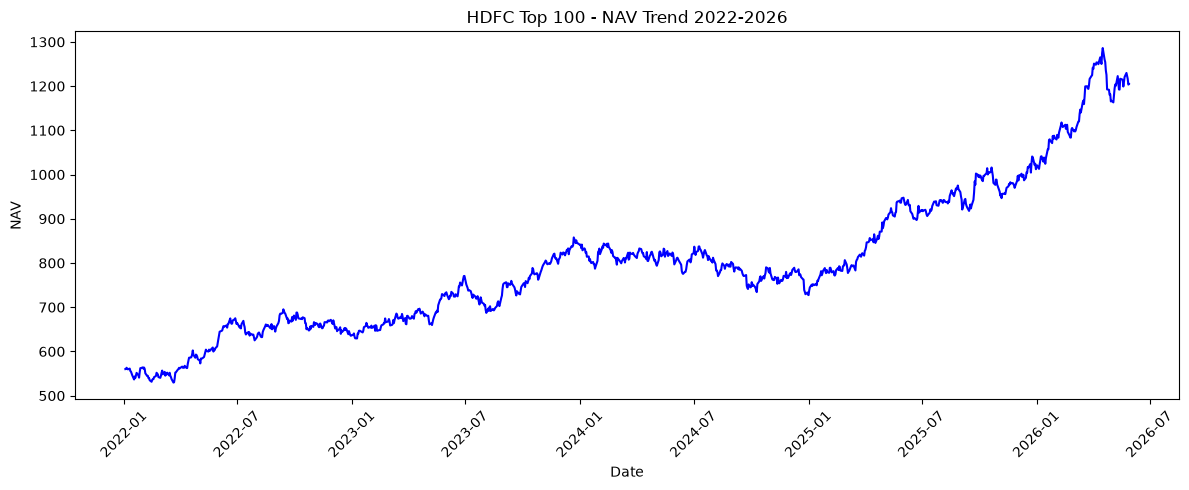

✅ NAV trend chart saved!


In [3]:
# Cell 2 - NAV Trend Analysis
nav['date'] = pd.to_datetime(nav['date'])

# Get one fund for example
sample = nav[nav['amfi_code'] == 125497]

plt.figure(figsize=(12, 5))
plt.plot(sample['date'], sample['nav'], color='blue')
plt.title('HDFC Top 100 - NAV Trend 2022-2026')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/nav_trend.png')
plt.show()
print("✅ NAV trend chart saved!")

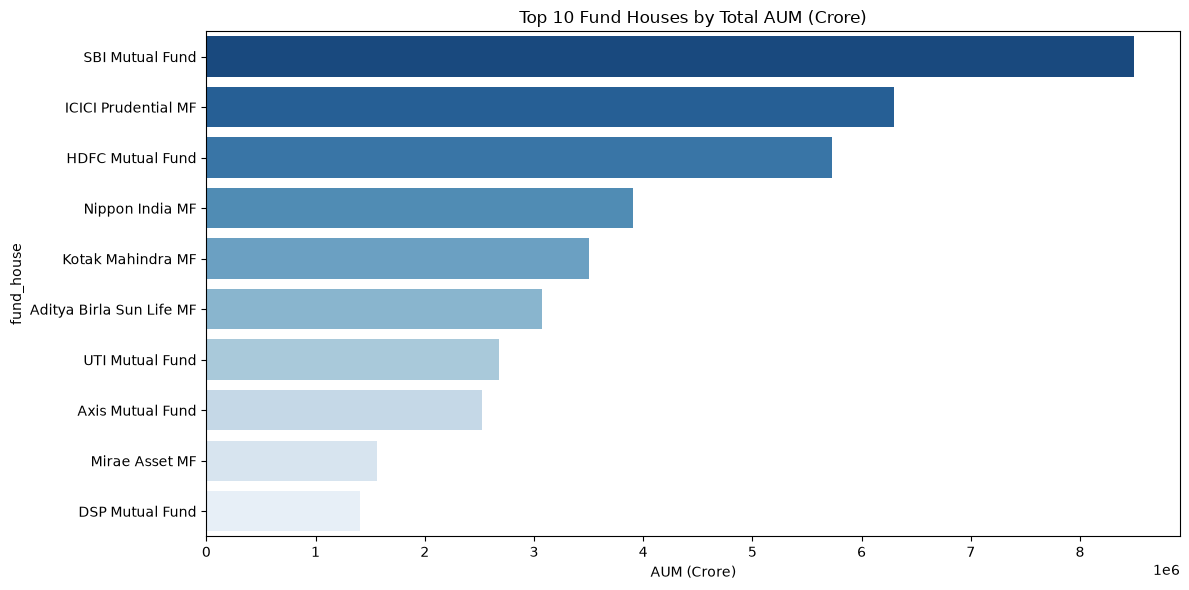

✅ AUM chart saved!


In [4]:
# Cell 3 - AUM Growth Bar Chart
plt.figure(figsize=(12, 6))
aum_grouped = aum.groupby('fund_house')['aum_crore'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=aum_grouped.values, y=aum_grouped.index, palette='Blues_r')
plt.title('Top 10 Fund Houses by Total AUM (Crore)')
plt.xlabel('AUM (Crore)')
plt.tight_layout()
plt.savefig('reports/aum_chart.png')
plt.show()
print("✅ AUM chart saved!")

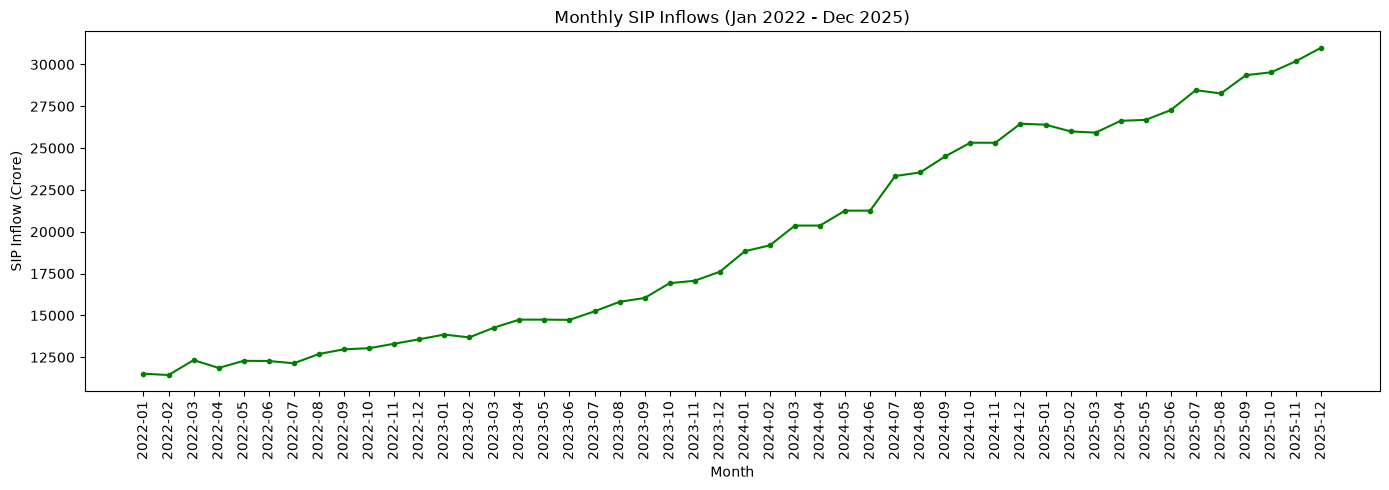

✅ SIP trend chart saved!


In [6]:
# Cell 4 - SIP Inflow Time Series
plt.figure(figsize=(14, 5))
plt.plot(sip['month'], sip['sip_inflow_crore'], 
         color='green', marker='o', markersize=3)
plt.title('Monthly SIP Inflows (Jan 2022 - Dec 2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('reports/sip_trend.png')
plt.show()
print("✅ SIP trend chart saved!")

['month', 'category', 'net_inflow_crore']


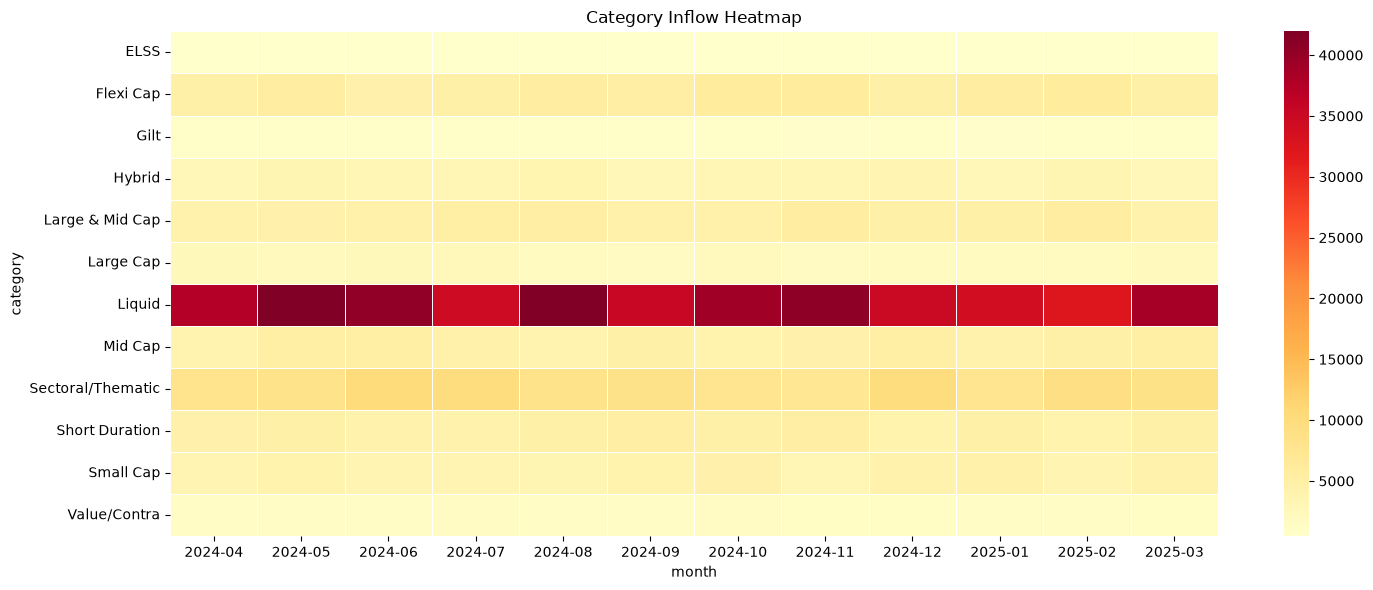

✅ Heatmap saved!


In [7]:
# Cell 5 - Category Inflow Heatmap
cat = pd.read_csv("data/raw/05_category_inflows.csv")
print(cat.columns.tolist())
cat_pivot = cat.pivot_table(index='category', columns='month', values=cat.columns[2], aggfunc='sum')

plt.figure(figsize=(15, 6))
sns.heatmap(cat_pivot, cmap='YlOrRd', linewidths=0.5)
plt.title('Category Inflow Heatmap')
plt.tight_layout()
plt.savefig('reports/category_heatmap.png')
plt.show()
print("✅ Heatmap saved!")


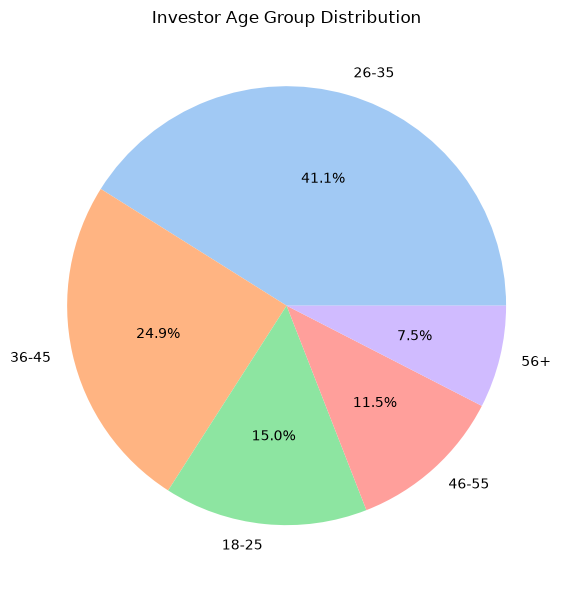

✅ Age distribution chart saved!


In [8]:
# Cell 6 - Investor Age Group Distribution
plt.figure(figsize=(10, 6))
age_dist = transactions['age_group'].value_counts()
plt.pie(age_dist.values, labels=age_dist.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'))
plt.title('Investor Age Group Distribution')
plt.tight_layout()
plt.savefig('reports/age_distribution.png')
plt.show()
print("✅ Age distribution chart saved!")

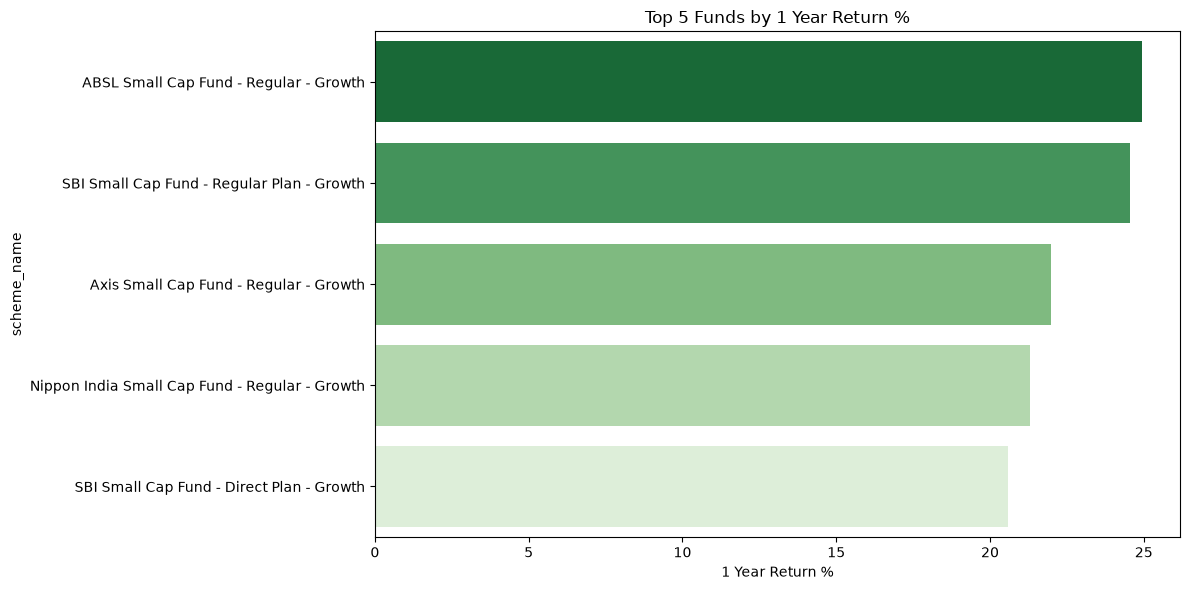

✅ Top 5 returns chart saved!


In [9]:
# Cell 7 - Top 5 Funds by 1 Year Return
plt.figure(figsize=(12, 6))
top5 = performance.nlargest(5, 'return_1yr_pct')
sns.barplot(x='return_1yr_pct', y='scheme_name', data=top5, palette='Greens_r')
plt.title('Top 5 Funds by 1 Year Return %')
plt.xlabel('1 Year Return %')
plt.tight_layout()
plt.savefig('reports/top5_returns.png')
plt.show()
print("✅ Top 5 returns chart saved!")

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


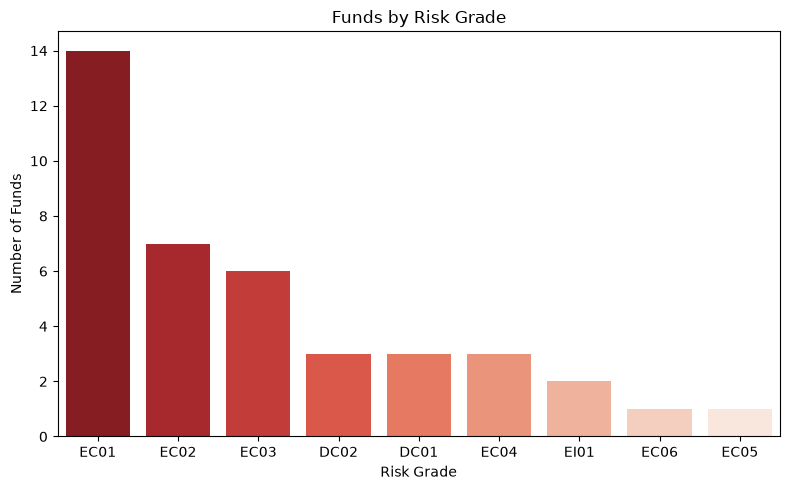

✅ Risk grade chart saved!


In [11]:
# Cell 8 - Funds by Risk Grade
plt.figure(figsize=(8, 5))
print(fund_master.columns.tolist())
risk_counts = fund_master.iloc[:, -1].value_counts()
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='Reds_r')
plt.title('Funds by Risk Grade')
plt.xlabel('Risk Grade')
plt.ylabel('Number of Funds')
plt.tight_layout()
plt.savefig('reports/risk_grade.png')
plt.show()
print("✅ Risk grade chart saved!")

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


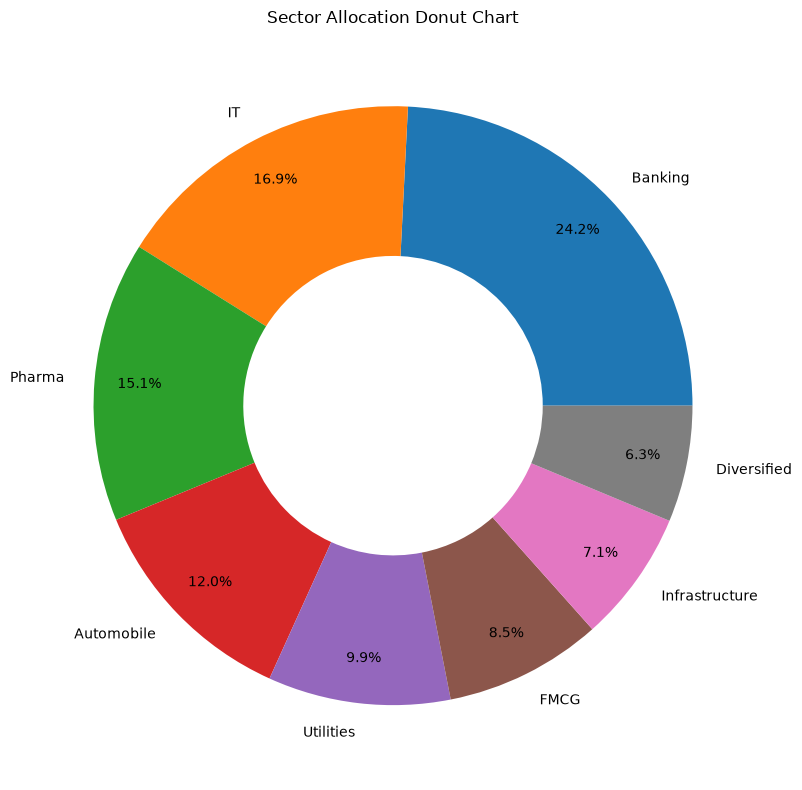

✅ Sector donut chart saved!


In [12]:
# Cell 9 - Sector Allocation Donut
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")
print(portfolio.columns.tolist())
sector_weights = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 8))
plt.pie(sector_weights.values, labels=sector_weights.index, 
        autopct='%1.1f%%', pctdistance=0.85,
        wedgeprops=dict(width=0.5))
plt.title('Sector Allocation Donut Chart')
plt.tight_layout()
plt.savefig('reports/sector_donut.png')
plt.show()
print("✅ Sector donut chart saved!")

In [13]:
# Cell 10 - EDA Key Findings Summary
findings = [
    "1. HDFC Top 100 NAV grew from 500 to 1200+ (2022-2026)",
    "2. SBI Mutual Fund has highest AUM among all fund houses",
    "3. Monthly SIP inflows grew from 12,500 to 30,000+ Crore",
    "4. Liquid funds dominate category inflows",
    "5. 41% investors are in 26-35 age group",
    "6. Small Cap funds have highest 1-year returns (20-25%)",
    "7. EC01 risk grade has most funds (14 funds)",
    "8. Banking sector has largest portfolio allocation",
    "9. 40 AMFI codes validated - 100% match",
    "10. 32,778 investor transactions analyzed"
]

print("=" * 60)
print("EDA KEY FINDINGS")
print("=" * 60)
for f in findings:
    print(f)
print("=" * 60)
print("✅ EDA Analysis Complete - 9 charts generated!")

EDA KEY FINDINGS
1. HDFC Top 100 NAV grew from 500 to 1200+ (2022-2026)
2. SBI Mutual Fund has highest AUM among all fund houses
3. Monthly SIP inflows grew from 12,500 to 30,000+ Crore
4. Liquid funds dominate category inflows
5. 41% investors are in 26-35 age group
6. Small Cap funds have highest 1-year returns (20-25%)
7. EC01 risk grade has most funds (14 funds)
8. Banking sector has largest portfolio allocation
9. 40 AMFI codes validated - 100% match
10. 32,778 investor transactions analyzed
✅ EDA Analysis Complete - 9 charts generated!
